# Cybersecurity Threat Detection & SOC Analytics

## Project Overview

This project analyses network traffic data to identify malicious activity,
common attack patterns and potential cybersecurity threats.

The analysis uses Python, SQL and Power BI to investigate security events
and generate actionable insights.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [30]:
file_path = "/content/Friday-WorkingHours-Morning.pcap_ISCX.csv.parquet"

df = pd.read_parquet(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [31]:
df.shape

(191033, 79)

In [32]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [33]:
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191033 entries, 0 to 191032
Data columns (total 79 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Destination Port                191033 non-null  int64  
 1   Flow Duration                   191033 non-null  int64  
 2   Total Fwd Packets               191033 non-null  int64  
 3   Total Backward Packets          191033 non-null  int64  
 4   Total Length of Fwd Packets     191033 non-null  int64  
 5   Total Length of Bwd Packets     191033 non-null  int64  
 6   Fwd Packet Length Max           191033 non-null  int64  
 7   Fwd Packet Length Min           191033 non-null  int64  
 8   Fwd Packet Length Mean          191033 non-null  float64
 9   Fwd Packet Length Std           191033 non-null  float64
 10  Bwd Packet Length Max           191033 non-null  int64  
 11  Bwd Packet Length Min           191033 non-null  int64  
 12  Bwd Packet Lengt

In [35]:
df["Label"].value_counts()

,count
Label,
BENIGN,189067
Bot,1966


In [36]:
# ==========================================
# STEP 3: DATA CLEANING
# ==========================================

# Make a copy so the original dataset remains unchanged
df_clean = df.copy()

# 1. Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# 2. Handle missing values in Flow Bytes/s
missing_flow_bytes = df_clean["Flow Bytes/s"].isna().sum()
print(f"Missing Flow Bytes/s values: {missing_flow_bytes}")

# Replace missing values with the median
df_clean["Flow Bytes/s"] = df_clean["Flow Bytes/s"].fillna(
    df_clean["Flow Bytes/s"].median()
)

# 3. Remove duplicated feature
duplicate_feature = "Fwd Header Length\\_duplicated\\_0"

if duplicate_feature in df_clean.columns:
    df_clean = df_clean.drop(columns=[duplicate_feature])
    print(f"Removed duplicated feature: {duplicate_feature}")

# 4. Clean Label values
df_clean["Label"] = df_clean["Label"].str.strip()

# Confirm final structure
print("\nCleaning complete.")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

print("\nMissing values remaining:")
print(df_clean.isnull().sum().sum())

print("\nLabel distribution:")
print(df_clean["Label"].value_counts())

Duplicate rows found: 6888
Missing Flow Bytes/s values: 28

Cleaning complete.
Rows: 184145
Columns: 79

Missing values remaining:
0

Label distribution:
Label
BENIGN    182192
Bot         1953
Name: count, dtype: int64


In [37]:
# ==========================================
# STEP 4: EXPLORATORY THREAT ANALYSIS
# ==========================================

# Basic dataset summary
print("Dataset shape:", df_clean.shape)

print("\nAttack distribution:")
print(df_clean["Label"].value_counts())

print("\nAttack percentages:")
print(
    df_clean["Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dataset shape: (184145, 79)

Attack distribution:
Label
BENIGN    182192
Bot         1953
Name: count, dtype: int64

Attack percentages:
Label
BENIGN    98.94
Bot        1.06
Name: proportion, dtype: float64


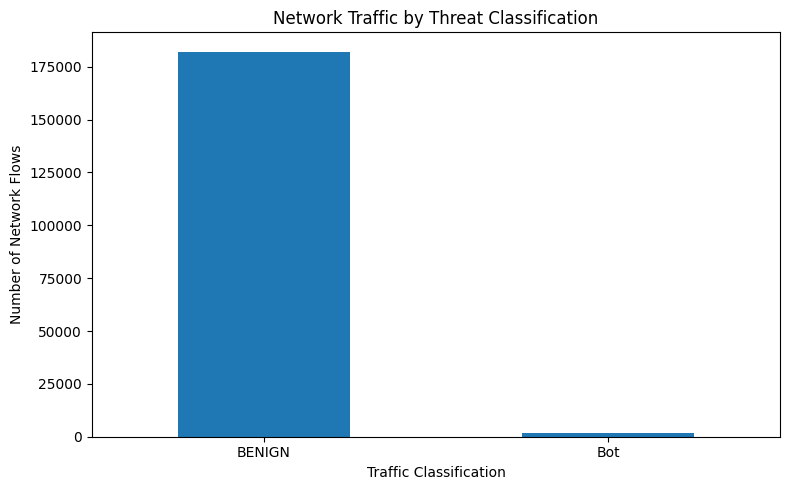

In [38]:
import matplotlib.pyplot as plt

label_counts = df_clean["Label"].value_counts()

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")

plt.title("Network Traffic by Threat Classification")
plt.xlabel("Traffic Classification")
plt.ylabel("Number of Network Flows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
top_ports = (
    df_clean["Destination Port"]
    .value_counts()
    .head(15)
)

print(top_ports)

Destination Port
53      87296
443     37376
80      19682
123      3434
8080     1248
22        748
389       709
88        691
21        319
137       319
465       310
3268      270
139       180
0         151
445       130
Name: count, dtype: int64


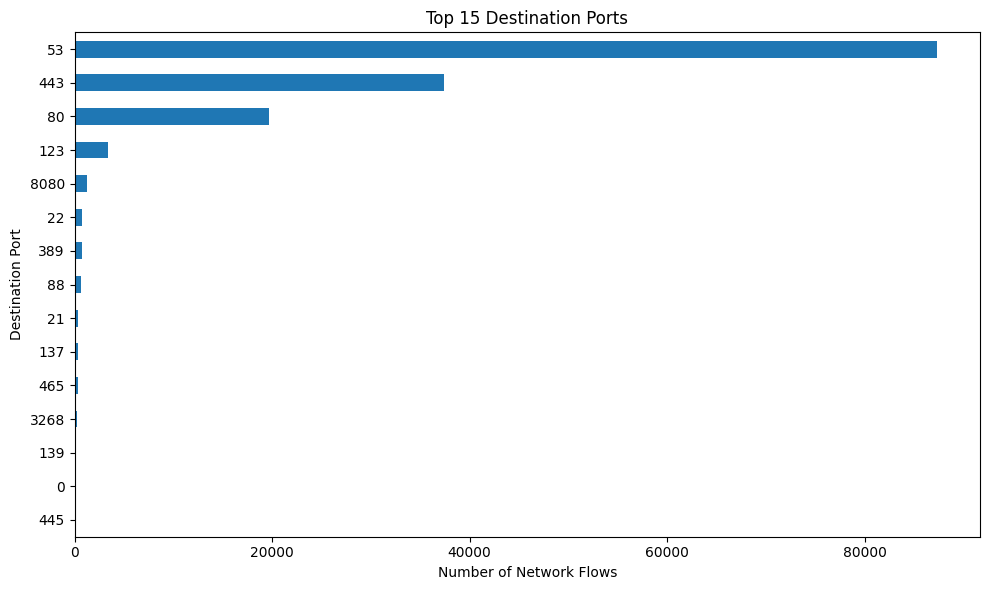

In [40]:
plt.figure(figsize=(10, 6))
top_ports.sort_values().plot(kind="barh")

plt.title("Top 15 Destination Ports")
plt.xlabel("Number of Network Flows")
plt.ylabel("Destination Port")
plt.tight_layout()
plt.show()

In [41]:
port_analysis = (
    df_clean.groupby(["Destination Port", "Label"])
    .size()
    .unstack(fill_value=0)
)

port_analysis["Total"] = port_analysis.sum(axis=1)

top_ports_by_volume = (
    port_analysis
    .sort_values("Total", ascending=False)
    .head(15)
)

top_ports_by_volume

Label,BENIGN,Bot,Total
Destination Port,,,
53,87296,0,87296
443,37376,0,37376
80,19682,0,19682
123,3434,0,3434
8080,0,1248,1248
22,748,0,748
389,709,0,709
88,691,0,691
137,319,0,319


In [42]:
bot_traffic = df_clean[df_clean["Label"] == "Bot"]

print("Total Bot flows:", len(bot_traffic))

print("\nBot destination ports:")
print(bot_traffic["Destination Port"].value_counts().head(20))

Total Bot flows: 1953

Bot destination ports:
Destination Port
8080     1248
53730       1
4089        1
52901       1
52907       1
52908       1
51740       1
51741       1
4172        1
4173        1
53938       1
53732       1
52909       1
2937        1
2935        1
4176        1
51742       1
53733       1
2951        1
52912       1
Name: count, dtype: int64


In [43]:
bot_port_percentage = (
    bot_traffic["Destination Port"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(bot_port_percentage.head(10))

Destination Port
8080     63.90
53730     0.05
4089      0.05
52901     0.05
52907     0.05
52908     0.05
51740     0.05
51741     0.05
4172      0.05
4173      0.05
Name: proportion, dtype: float64


In [44]:
comparison = df_clean.groupby("Label")[
    [
        "Flow Duration",
        "Total Fwd Packets",
        "Total Backward Packets",
        "Flow Bytes/s",
        "Flow Packets/s",
        "Packet Length Mean"
    ]
].mean()

comparison

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean
Label,,,,,,
BENIGN,1.219850e+07,14.370911,17.137701,inf,inf,107.473338
Bot,3.532787e+05,3.208397,3.359447,inf,inf,51.561958


<Figure size 1000x600 with 0 Axes>

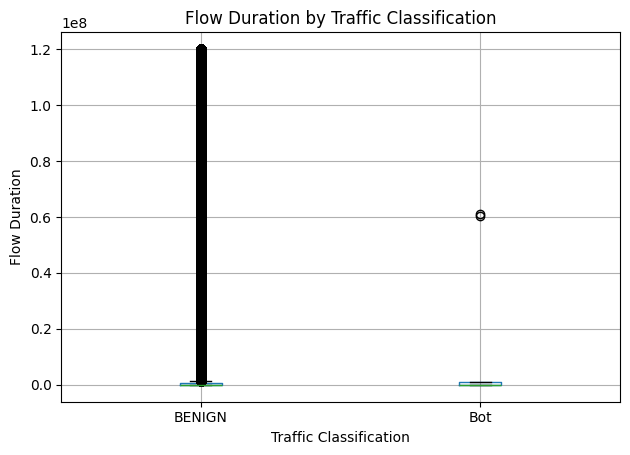

In [45]:
plt.figure(figsize=(10, 6))

df_clean.boxplot(
    column="Flow Duration",
    by="Label"
)

plt.title("Flow Duration by Traffic Classification")
plt.suptitle("")
plt.xlabel("Traffic Classification")
plt.ylabel("Flow Duration")
plt.tight_layout()
plt.show()

In [46]:
# Check for infinite values

import numpy as np

inf_counts = np.isinf(
    df_clean.select_dtypes(include=np.number)
).sum()

print("Columns containing infinite values:")
print(inf_counts[inf_counts > 0])

Columns containing infinite values:
Flow Bytes/s       73
Flow Packets/s    101
dtype: int64


In [47]:
# Replace infinite values with NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("Infinite values remaining:")
print(
    np.isinf(
        df_clean.select_dtypes(include=np.number)
    ).sum().sum()
)

Infinite values remaining:
0


In [48]:
packet_features = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Packet Length Mean",
    "Packet Length Std"
]

packet_comparison = (
    df_clean.groupby("Label")[packet_features]
    .mean()
    .T
)

packet_comparison

Label,BENIGN,Bot
Total Fwd Packets,14.370911,3.208397
Total Backward Packets,17.137701,3.359447
Total Length of Fwd Packets,597.238485,2663.017921
Total Length of Bwd Packets,29758.919519,64.184844
Packet Length Mean,107.473338,51.561958
Packet Length Std,135.777511,96.373723


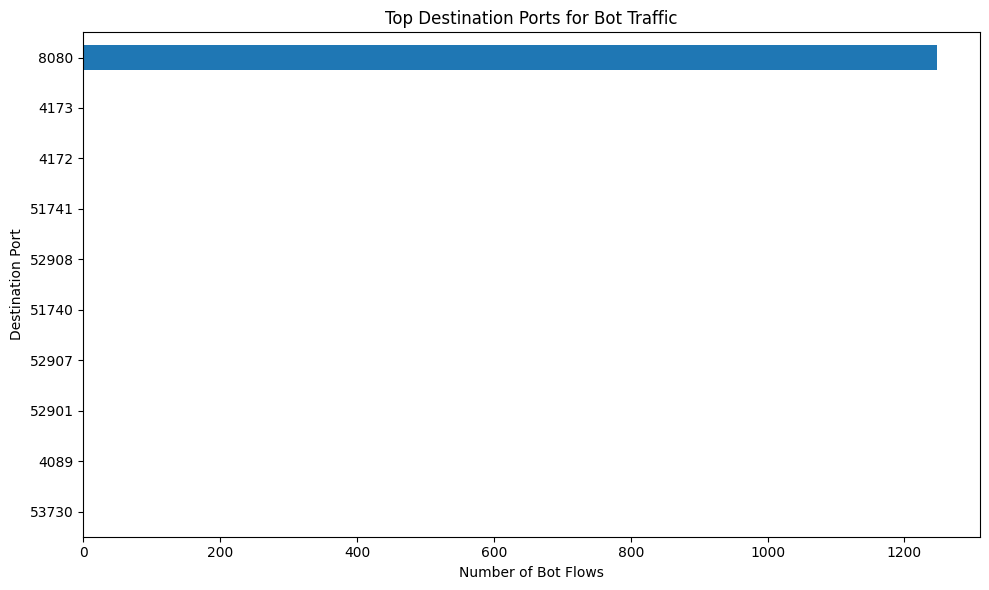

In [49]:
bot_ports = (
    bot_traffic["Destination Port"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

bot_ports.sort_values().plot(kind="barh")

plt.title("Top Destination Ports for Bot Traffic")
plt.xlabel("Number of Bot Flows")
plt.ylabel("Destination Port")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

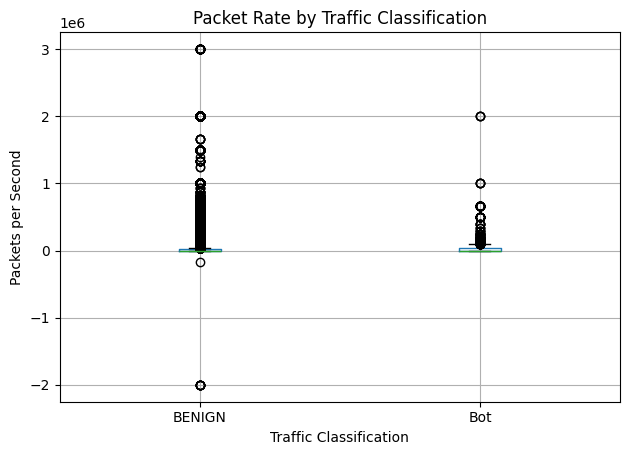

In [50]:
plt.figure(figsize=(10, 6))

df_clean.boxplot(
    column="Flow Packets/s",
    by="Label"
)

plt.title("Packet Rate by Traffic Classification")
plt.suptitle("")
plt.xlabel("Traffic Classification")
plt.ylabel("Packets per Second")
plt.tight_layout()
plt.show()

In [51]:
# ==========================================
# STEP 5: RULE-BASED THREAT DETECTION
# ==========================================

# Create a rule-based detection flag
df_clean["Suspicious_Flow"] = (
    (df_clean["Destination Port"] == 8080) &
    (df_clean["Total Length of Bwd Packets"] < 100)
)

# Count flagged flows
print("Suspicious flows detected:")
print(df_clean["Suspicious_Flow"].value_counts())

Suspicious flows detected:
Suspicious_Flow
False    183635
True        510
Name: count, dtype: int64


In [52]:
detection_results = pd.crosstab(
    df_clean["Suspicious_Flow"],
    df_clean["Label"]
)

detection_results

Label,BENIGN,Bot
Suspicious_Flow,,
False,182192,1443
True,0,510


In [53]:
missed_bots = df_clean[
    (df_clean["Label"] == "Bot") &
    (df_clean["Suspicious_Flow"] == False)
]

print("Bot flows missed by our first rule:", len(missed_bots))

print("\nDestination ports of missed Bot flows:")
print(missed_bots["Destination Port"].value_counts().head(20))

Bot flows missed by our first rule: 1443

Destination ports of missed Bot flows:
Destination Port
8080     738
53730      1
4089       1
52901      1
52907      1
52908      1
51740      1
51741      1
4172       1
4173       1
53938      1
53732      1
52909      1
2937       1
2935       1
4176       1
51742      1
53733      1
2951       1
52912      1
Name: count, dtype: int64


In [54]:
missed_bot_summary = missed_bots[
    [
        "Flow Duration",
        "Total Fwd Packets",
        "Total Backward Packets",
        "Total Length of Fwd Packets",
        "Total Length of Bwd Packets",
        "Packet Length Mean"
    ]
].describe()

missed_bot_summary

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean
count,1.443000e+03,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000
mean,1.338777e+05,3.309771,3.514207,3604.134442,80.682606,68.837495
std,2.254536e+06,4.677130,8.921388,21404.886442,89.392714,242.903514
min,0.000000e+00,1.000000,1.000000,6.000000,6.000000,6.000000
25%,3.900000e+01,1.000000,1.000000,6.000000,6.000000,6.000000
50%,5.994100e+04,4.000000,3.000000,206.000000,134.000000,35.300000
75%,7.657350e+04,4.000000,3.000000,207.000000,134.000000,42.625000
max,6.100390e+07,39.000000,85.000000,207930.000000,626.000000,1797.637931


In [55]:
# ==========================================
# STEP 5B: SECOND DETECTION RULE
# ==========================================

df_clean["Suspicious_Flow_V2"] = (
    (df_clean["Destination Port"] == 8080) &
    (df_clean["Total Fwd Packets"] <= 5) &
    (df_clean["Total Backward Packets"] <= 5) &
    (df_clean["Packet Length Mean"] < 100)
)

print("Suspicious flows detected by V2:")
print(df_clean["Suspicious_Flow_V2"].value_counts())

Suspicious flows detected by V2:
Suspicious_Flow_V2
False    182969
True       1176
Name: count, dtype: int64


In [56]:
detection_results_v2 = pd.crosstab(
    df_clean["Suspicious_Flow_V2"],
    df_clean["Label"]
)

detection_results_v2

Label,BENIGN,Bot
Suspicious_Flow_V2,,
False,182192,777
True,0,1176


In [57]:
tp = (
    (df_clean["Suspicious_Flow_V2"] == True) &
    (df_clean["Label"] == "Bot")
).sum()

fp = (
    (df_clean["Suspicious_Flow_V2"] == True) &
    (df_clean["Label"] == "BENIGN")
).sum()

fn = (
    (df_clean["Suspicious_Flow_V2"] == False) &
    (df_clean["Label"] == "Bot")
).sum()

tn = (
    (df_clean["Suspicious_Flow_V2"] == False) &
    (df_clean["Label"] == "BENIGN")
).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Negatives: {tn}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True Positives: 1176
False Positives: 0
False Negatives: 777
True Negatives: 182192
Precision: 100.00%
Recall: 60.22%


In [58]:
print("Missing values by column:")

missing_values = df_clean.isnull().sum()

print(missing_values[missing_values > 0])

Missing values by column:
Flow Bytes/s       73
Flow Packets/s    101
dtype: int64


In [59]:
# Handle missing values created from infinite rate values

rate_columns = ["Flow Bytes/s", "Flow Packets/s"]

for column in rate_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


In [60]:
# ==========================================
# STEP 6: PREPARE DATA FOR MACHINE LEARNING
# ==========================================

# Create a copy for machine learning
ml_df = df_clean.copy()

# Remove rule-based detection columns
ml_df = ml_df.drop(
    columns=["Suspicious_Flow", "Suspicious_Flow_V2"]
)

# Convert the target into binary values
# BENIGN = 0
# Bot = 1

ml_df["Target"] = (
    ml_df["Label"] == "Bot"
).astype(int)

# Separate features and target
X = ml_df.drop(columns=["Label", "Target"])
y = ml_df["Target"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: (184145, 78)
Target: (184145,)

Target distribution:
Target
0    182192
1      1953
Name: count, dtype: int64


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (147316, 78)
Test set: (36829, 78)

Training target distribution:
Target
0    145754
1      1562
Name: count, dtype: int64

Test target distribution:
Target
0    36438
1      391
Name: count, dtype: int64


In [62]:
# ==========================================
# STEP 6C: RANDOM FOREST THREAT DETECTION
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Model training complete!")

Training Random Forest...
Model training complete!


In [63]:
# Generate predictions on unseen test data

y_pred = rf_model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 36829


In [64]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "Bot"]
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     36438
         Bot       0.99      0.96      0.98       391

    accuracy                           1.00     36829
   macro avg       1.00      0.98      0.99     36829
weighted avg       1.00      1.00      1.00     36829



Confusion Matrix:
[[36436     2]
 [   17   374]]


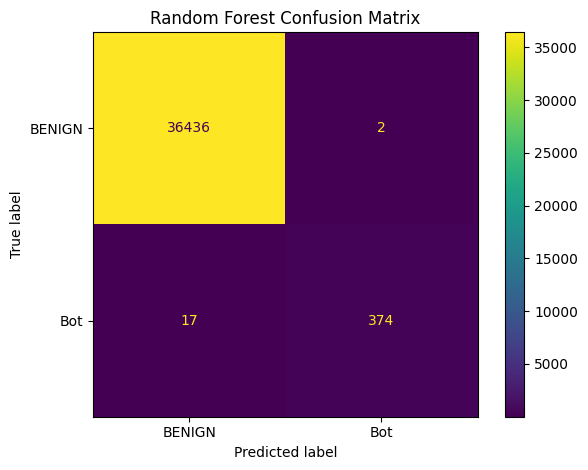

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "Bot"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [66]:
# ==========================================
# STEP 7: FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 most important features:")
print(feature_importance.head(15))

Top 15 most important features:
                        Feature  Importance
0              Destination Port    0.157521
12       Bwd Packet Length Mean    0.096240
66       Init_Win_bytes_forward    0.075604
54         Avg Bwd Segment Size    0.072434
67      Init_Win_bytes_backward    0.069030
52          Average Packet Size    0.057527
5   Total Length of Bwd Packets    0.034207
10        Bwd Packet Length Max    0.033469
65            Subflow Bwd Bytes    0.029656
40           Packet Length Mean    0.027636
11        Bwd Packet Length Min    0.026002
37                Bwd Packets/s    0.025381
38            Min Packet Length    0.020824
29                  Bwd IAT Min    0.015229
69         min_seg_size_forward    0.014628


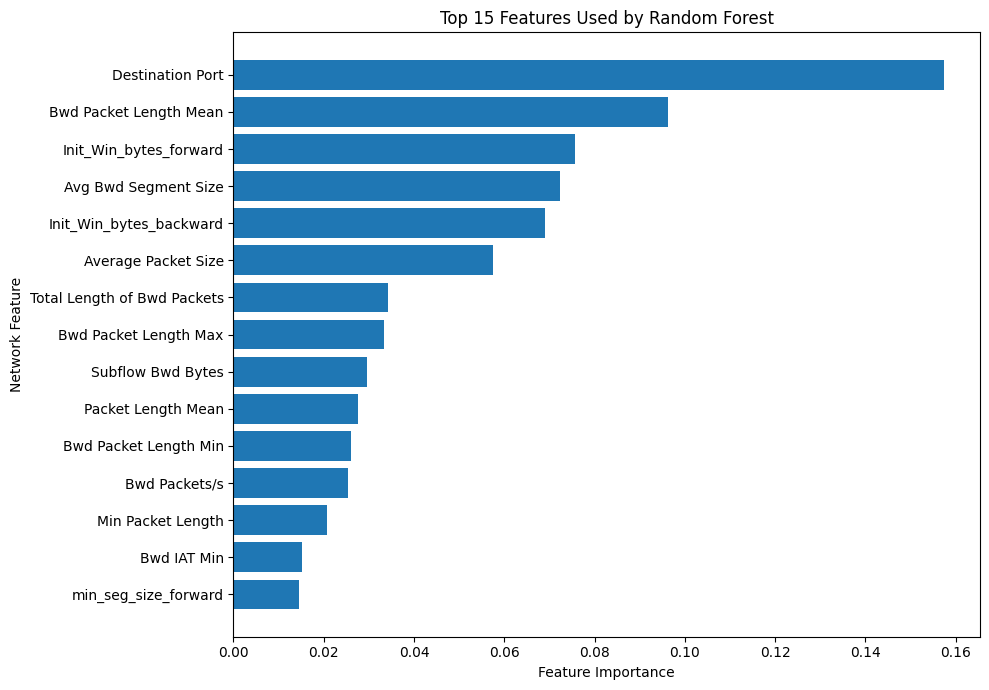

In [67]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Network Feature")
plt.title("Top 15 Features Used by Random Forest")
plt.tight_layout()
plt.show()

In [70]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 features by permutation importance:")
print(permutation_df.head(15))

Top 15 features by permutation importance:
                        Feature  Importance
0              Destination Port    0.713735
66       Init_Win_bytes_forward    0.202637
67      Init_Win_bytes_backward    0.175822
48               URG Flag Count    0.064274
1                 Flow Duration    0.022596
16                Flow IAT Mean    0.015590
18                 Flow IAT Max    0.010313
17                 Flow IAT Std    0.008988
37                Bwd Packets/s    0.007334
12       Bwd Packet Length Mean    0.005708
15               Flow Packets/s    0.005149
69         min_seg_size_forward    0.005140
36                Fwd Packets/s    0.004911
19                 Flow IAT Min    0.004087
5   Total Length of Bwd Packets    0.004071


In [71]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Probability predictions
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate scores
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 1.0000
PR-AUC: 0.9979


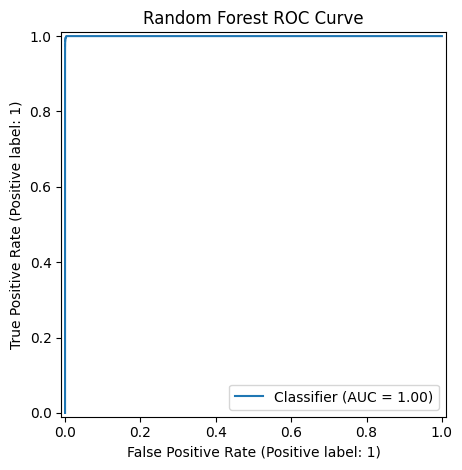

In [72]:
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.show()

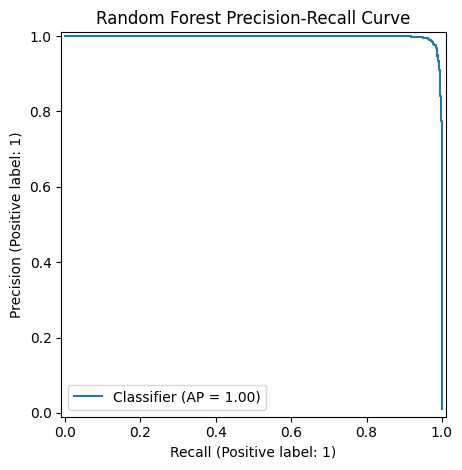

In [73]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest Precision-Recall Curve")
plt.tight_layout()
plt.show()

# SQL Security Analysis

This section uses SQL to investigate network traffic patterns, Bot activity,
destination ports, packet behaviour, and suspicious network flows.

The objective is to demonstrate how SQL can be used to extract actionable
cybersecurity insights from network-flow data.

In [74]:
import sqlite3

# Create a SQLite database
conn = sqlite3.connect("cybersecurity_analysis.db")

# Save the cleaned dataset as a SQL table
df_clean.to_sql(
    "network_traffic",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")

SQL database created successfully!


In [75]:
query = """
SELECT COUNT(*) AS total_network_flows
FROM network_traffic;
"""

pd.read_sql_query(query, conn)

,total_network_flows
0,184145


In [76]:
query = """
SELECT
    Label,
    COUNT(*) AS flow_count
FROM network_traffic
GROUP BY Label
ORDER BY flow_count DESC;
"""

pd.read_sql_query(query, conn)

,Label,flow_count
0,BENIGN,182192
1,Bot,1953


In [77]:
query = """
SELECT
    "Destination Port" AS destination_port,
    COUNT(*) AS bot_flow_count
FROM network_traffic
WHERE Label = 'Bot'
GROUP BY "Destination Port"
ORDER BY bot_flow_count DESC
LIMIT 15;
"""

pd.read_sql_query(query, conn)

,destination_port,bot_flow_count
0,8080,1248
1,53938,1
2,53935,1
3,53932,1
4,53931,1
5,53901,1
6,53900,1
7,53899,1
8,53898,1
9,53897,1


In [78]:
query = """
SELECT
    "Destination Port" AS destination_port,
    Label,
    COUNT(*) AS flow_count
FROM network_traffic
WHERE "Destination Port" IN (
    SELECT "Destination Port"
    FROM network_traffic
    WHERE Label = 'Bot'
    GROUP BY "Destination Port"
    ORDER BY COUNT(*) DESC
    LIMIT 10
)
GROUP BY "Destination Port", Label
ORDER BY destination_port, flow_count DESC;
"""

pd.read_sql_query(query, conn)

,destination_port,Label,flow_count
0,8080,Bot,1248
1,53897,BENIGN,2
2,53897,Bot,1
3,53898,Bot,1
4,53899,Bot,1
5,53900,Bot,1
6,53901,Bot,1
7,53931,BENIGN,2
8,53931,Bot,1
9,53932,Bot,1


In [79]:
query = """
SELECT
    Label,
    ROUND(AVG("Flow Duration"), 2) AS avg_flow_duration,
    ROUND(AVG("Total Fwd Packets"), 2) AS avg_fwd_packets,
    ROUND(AVG("Total Backward Packets"), 2) AS avg_bwd_packets,
    ROUND(AVG("Total Length of Fwd Packets"), 2) AS avg_fwd_bytes,
    ROUND(AVG("Total Length of Bwd Packets"), 2) AS avg_bwd_bytes,
    ROUND(AVG("Packet Length Mean"), 2) AS avg_packet_length
FROM network_traffic
GROUP BY Label;
"""

pd.read_sql_query(query, conn)

,Label,avg_flow_duration,avg_fwd_packets,avg_bwd_packets,avg_fwd_bytes,avg_bwd_bytes,avg_packet_length
0,BENIGN,12198495.87,14.37,17.14,597.24,29758.92,107.47
1,Bot,353278.67,3.21,3.36,2663.02,64.18,51.56


In [80]:
query = """
SELECT
    Label,
    ROUND(
        AVG(
            CASE
                WHEN "Destination Port" = 8080 THEN 1.0
                ELSE 0.0
            END
        ) * 100,
        2
    ) AS pct_flows_to_port_8080
FROM network_traffic
GROUP BY Label;
"""

pd.read_sql_query(query, conn)

,Label,pct_flows_to_port_8080
0,BENIGN,0.0
1,Bot,63.9


In [81]:
query = """
SELECT
    COUNT(*) AS suspicious_flow_count
FROM network_traffic
WHERE
    "Destination Port" = 8080
    AND "Total Fwd Packets" <= 5
    AND "Total Backward Packets" <= 5
    AND "Packet Length Mean" < 100;
"""

pd.read_sql_query(query, conn)

,suspicious_flow_count
0,1176


In [82]:
query = """
SELECT
    Label,
    COUNT(*) AS suspicious_flow_count
FROM network_traffic
WHERE
    "Destination Port" = 8080
    AND "Total Fwd Packets" <= 5
    AND "Total Backward Packets" <= 5
    AND "Packet Length Mean" < 100
GROUP BY Label
ORDER BY suspicious_flow_count DESC;
"""

pd.read_sql_query(query, conn)

,Label,suspicious_flow_count
0,Bot,1176


In [83]:
query = """
WITH port_summary AS (
    SELECT
        "Destination Port" AS destination_port,
        COUNT(*) AS total_flows,
        SUM(CASE WHEN Label = 'Bot' THEN 1 ELSE 0 END) AS bot_flows,
        SUM(CASE WHEN Label = 'BENIGN' THEN 1 ELSE 0 END) AS benign_flows
    FROM network_traffic
    GROUP BY "Destination Port"
),

ranked_ports AS (
    SELECT
        destination_port,
        total_flows,
        bot_flows,
        benign_flows,
        ROUND(
            100.0 * bot_flows / NULLIF(total_flows, 0),
            2
        ) AS bot_percentage,
        RANK() OVER (
            ORDER BY bot_flows DESC
        ) AS bot_rank
    FROM port_summary
)

SELECT
    destination_port,
    total_flows,
    bot_flows,
    benign_flows,
    bot_percentage,
    bot_rank
FROM ranked_ports
WHERE bot_flows > 0
ORDER BY bot_rank, destination_port
LIMIT 20;
"""

pd.read_sql_query(query, conn)

,destination_port,total_flows,bot_flows,benign_flows,bot_percentage,bot_rank
0,8080,1248,1248,0,100.0,1
1,1841,2,1,1,50.0,2
2,1845,2,1,1,50.0,2
3,1846,1,1,0,100.0,2
4,1847,2,1,1,50.0,2
5,1848,2,1,1,50.0,2
6,1851,2,1,1,50.0,2
7,1852,2,1,1,50.0,2
8,1853,2,1,1,50.0,2
9,1854,2,1,1,50.0,2


In [84]:
df_clean.to_csv(
    "cybersecurity_cleaned.csv",
    index=False
)

print("CSV exported successfully!")

CSV exported successfully!


# Project Summary

## Cybersecurity Threat Detection Using Machine Learning & Network Traffic Analysis

### Project Objective

The objective of this project was to analyse network traffic data and develop a
system capable of identifying malicious Bot activity.

The project combines exploratory data analysis, rule-based threat detection,
SQL analysis and machine learning to investigate patterns associated with
malicious network traffic.

---

## Dataset

After data cleaning, the dataset contained:

- 184,145 network flows
- 182,192 BENIGN flows
- 1,953 Bot flows
- 78 network traffic features used for machine learning
- Approximately 1.06% of traffic was labelled as Bot activity

The dataset was highly imbalanced, making precision, recall, F1-score and
Precision-Recall AUC more informative than accuracy alone.

---

## Key Findings

Network analysis identified substantial differences between BENIGN and Bot
traffic.

Notable findings included:

- 63.9% of Bot flows targeted destination port 8080.
- No BENIGN flows in the analysed dataset targeted port 8080.
- Bot flows contained fewer forward and backward packets on average.
- Bot traffic had substantially lower backward traffic volume.
- Bot flows had a lower average packet length than BENIGN traffic.
- Destination port, TCP initial window characteristics, flow timing and
  backward traffic characteristics were important predictors of Bot activity.

---

## Rule-Based Threat Detection

An initial rule-based detector was developed using network traffic
characteristics identified during exploratory analysis.

The improved rule-based detector achieved:

- Precision: 100%
- Recall: 60.22%
- True Positives: 1,176
- False Positives: 0

The rule-based approach demonstrated high precision but failed to detect a
substantial proportion of Bot traffic.

---

## Machine Learning Model

A class-weighted Random Forest classifier was trained using an 80/20
stratified train-test split.

On the held-out test set, the model produced:

- True Positives: 374
- True Negatives: 36,436
- False Positives: 2
- False Negatives: 17
- Bot Precision: approximately 99.47%
- Bot Recall: approximately 95.65%
- Bot F1-score: approximately 97.5%
- ROC-AUC: 1.0000
- PR-AUC: 0.9979

The machine-learning approach substantially improved Bot detection compared
with the rule-based baseline while maintaining a very low false-positive rate.

---

## Model Interpretation

Random Forest feature importance and permutation importance were used to
investigate the model's predictions.

Permutation importance identified Destination Port as the strongest feature,
followed by:

- Init_Win_bytes_forward
- Init_Win_bytes_backward
- URG Flag Count
- Flow Duration
- Flow IAT Mean
- Flow IAT Max
- Flow IAT Std
- Bwd Packets/s
- Bwd Packet Length Mean

These results indicate that destination-port information, TCP connection
characteristics, flow timing and backward traffic behaviour contributed to
Bot detection.

---

## SQL Analysis

SQLite was used to investigate the cleaned network traffic dataset.

The SQL analysis included:

- Traffic volume analysis
- Bot activity by destination port
- BENIGN vs Bot traffic comparison
- CASE-based security analysis
- Rule-based suspicious-flow detection
- Subqueries
- Common Table Expressions (CTEs)
- Window functions and port ranking

SQL reproduced the rule-based detection logic and identified 1,176 suspicious
Bot flows with no BENIGN flows flagged by that rule in this dataset.

---

## Limitations

The model achieved very strong performance, but the results should be
interpreted carefully.

Destination Port was particularly influential, and a large proportion of Bot
traffic targeted port 8080. The random train-test split also contains flows
from the same underlying dataset and environment.

Therefore, model performance may be lower when applied to network traffic from
different environments, attack types or time periods.

Future work could evaluate the model using independent network datasets,
time-based validation and additional attack categories.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- SQL
- SQLite
- Google Colab
- Git/GitHub